In [ ]:
import os
import numpy as np
import pandas as pd
import random
import time
import gc
import math
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Dense, Activation, ZeroPadding1D,
    GlobalAveragePooling1D, Add, Concatenate, Dropout, BatchNormalization, Input, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

random.seed(20)
np.random.seed(20)
tf.random.set_seed(20)

tf.config.optimizer.set_jit(False)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')


2026-05-18 15:13:57.513073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779117237.914510      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779117238.013109      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779117238.960122      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779117238.960222      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779117238.960226      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
config = {
    "data_dir": "/kaggle/input/datasets/lampdp/masque-300-web", 
    
    "batch_size": 50,
    "learning_rate": 0.001,   # Tốc độ học khởi tạo
    "seq_length": 5000,        # Độ dài chuỗi trích xuất tối đa
    "max_epochs": 150,
    "base_patience": 20,       # Số epoch chờ trước khi dừng hẳn (Early Stopping)
    "lr_patience": 5,          # Số epoch chờ trước khi giảm Learning Rate
    
    "dir_dilations": True,
    "time_dilations": True,
    "size_dilations": True,    # Bật Dilated Convolution cho chuỗi Size
    "inter_time": True,
    "scale_metadata": True,
    "test_size": 0.1,
    "val_size": 0.05,
    
    # Kích hoạt cả 4 nguồn dữ liệu: Direction, Time, Size, và Metadata
    "features_to_use": ["dir", "time", "size", "metadata"],
    
    # Cấu hình Feature Selection
    "use_feature_selection": True, 
    "num_selected_metadata": 9,    # Giữ lại K đặc trưng metadata tốt nhất
    
    
    # CẤU HÌNH DATA AUGMENTATION
    "use_augmentation": True,
    
    # Xác suất (0.0 -> 1.0) kích hoạt từng phương pháp trên MỖI BẢN SAO
    "prob_time_jitter": 0.5,   # 50% khả năng bị lệch thời gian
    "prob_size_scale": 0.5,    # 50% khả năng bị co giãn dung lượng
    "prob_dropout": 0.5,       # 50% khả năng bị rớt gói tin
    "prob_noise": 0.5,         # 50% khả năng bị nhiễu Gaussian
    
    # Cường độ của các phương pháp (chỉ dùng nếu phương pháp đó được kích hoạt)
    "aug_time_jitter": 0.2,    
    "aug_size_scale": 0.2,     
    "aug_dropout_rate": 0.1,   
    "aug_noise_std": 0.05      
}

In [ ]:
def load_and_preprocess_data(config):
    data_dir = config['data_dir']
    seq_length = config['seq_length']
    
    dir_seqs, time_seqs, size_seqs, metadatas, labels = [], [], [], [], []
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"Found {len(classes)} classes (folders).")
    
    for label_name in tqdm(classes, desc="Processing folders"):
        class_dir = os.path.join(data_dir, label_name)
        files = [f for f in os.listdir(class_dir) if f.endswith('.csv')]
        
        for file in files:
            filepath = os.path.join(class_dir, file)
            try:
                df = pd.read_csv(filepath, sep=';')
            except:
                continue
                
            if len(df) == 0: continue
                
            dirs = df['direction'].values
            dirs = np.where(dirs == 0, -1, 1)
            times = df['relative_time'].values
            lengths = df['length'].values 
            
            # --- Sequence Processing ---
            dir_seq = np.zeros(seq_length, dtype=np.int8)
            time_seq = np.zeros(seq_length, dtype=np.float32)
            size_seq = np.zeros(seq_length, dtype=np.float32) 
            
            limit = min(len(dirs), seq_length)
            dir_seq[:limit] = dirs[:limit]
            time_seq[:limit] = times[:limit]
            size_seq[:limit] = lengths[:limit] 
            
            # --- Metadata Processing (13 features) ---
            in_mask = (dirs == -1)
            out_mask = (dirs == 1)
            total_incoming = np.sum(in_mask)
            total_outgoing = np.sum(out_mask)
            total_packets = total_incoming + total_outgoing
            total_time = times[-1] if total_packets > 0 else 0.0
            
            if total_packets == 0:
                metadata = np.zeros(13, dtype=np.float32)
            else:
                f1, f2, f3 = total_packets, total_incoming, total_outgoing
                f4 = total_incoming / total_packets
                f5 = total_outgoing / total_packets
                f6, f7 = total_time, total_time / total_packets
                
                mean_size_in = np.mean(lengths[in_mask]) if total_incoming > 0 else 0.0
                mean_size_out = np.mean(lengths[out_mask]) if total_outgoing > 0 else 0.0
                mean_size_total = np.mean(lengths) if total_packets > 0 else 0.0
                
                ratio_in_total = mean_size_in / mean_size_total if mean_size_total > 0 else 0.0
                ratio_out_total = mean_size_out / mean_size_total if mean_size_total > 0 else 0.0
                
                times_in, times_out = times[in_mask], times[out_mask]
                mean_time_in = np.mean(np.diff(times_in)) if len(times_in) > 1 else 0.0
                mean_time_out = np.mean(np.diff(times_out)) if len(times_out) > 1 else 0.0
                
                metadata = np.array([
                    f1, f2, f3, f4, f5, f6, f7, 
                    mean_size_out, mean_size_in, 
                    ratio_in_total, ratio_out_total, 
                    mean_time_in, mean_time_out
                ], dtype=np.float32)
                
            dir_seqs.append(dir_seq)
            time_seqs.append(time_seq)
            size_seqs.append(size_seq) 
            metadatas.append(metadata)
            labels.append(label_name)

    # --- Normalize & Reshape ---
    dir_seqs = np.expand_dims(np.array(dir_seqs), axis=-1)
    time_seqs = np.array(time_seqs)
    if config['inter_time']:
        inter_time_seqs = np.zeros_like(time_seqs)
        inter_time_seqs[:, 1:] = time_seqs[:, 1:] - time_seqs[:, :-1]
        time_seqs = inter_time_seqs
    time_seqs = np.expand_dims(time_seqs, axis=-1)
    size_seqs = np.expand_dims(np.array(size_seqs) / 1500.0, axis=-1)
    
    metadatas = np.array(metadatas)
    le = LabelEncoder()
    y_categorical = to_categorical(le.fit_transform(labels))
    
    # --- Train/Test Split ---
    X_dir_train, X_dir_test, X_time_train, X_time_test, X_size_train, X_size_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
        dir_seqs, time_seqs, size_seqs, metadatas, y_categorical, test_size=config['test_size'], random_state=42, stratify=y_categorical
    )
    
    if config['scale_metadata']:
        scaler = StandardScaler()
        X_meta_train = scaler.fit_transform(X_meta_train)
        X_meta_test = scaler.transform(X_meta_test)
        
    # --- Feature Selection Analysis ---
    if config['use_feature_selection']:
        k = config['num_selected_metadata']
        selector = SelectKBest(score_func=f_classif, k=k)
        X_meta_train_new = selector.fit_transform(X_meta_train, np.argmax(y_train, axis=1))
        X_meta_test = selector.transform(X_meta_test)
        X_meta_train = X_meta_train_new
        
        feature_names = [
            "total_packets", "total_incoming", "total_outgoing", 
            "ratio_incoming", "ratio_outgoing", "total_time", "time_per_packet",
            "mean_size_forward", "mean_size_backward", "ratio_in_total_size", 
            "ratio_out_total_size", "avg_sec_incoming", "avg_sec_outgoing"
        ]
        
        scores = selector.scores_
        sorted_indices = np.argsort(scores)[::-1]
        
        print("\nBẢNG XẾP HẠNG ĐỘ QUAN TRỌNG CỦA TẤT CẢ FEATURE (ANOVA F-SCORE):")
        print("-" * 65)
        for i, idx in enumerate(sorted_indices):
            status = "[SELECTED]" if i < k else "[EXCLUDED]"
            print(f"{i+1:>2}. {feature_names[idx]:<25} | Score: {scores[idx]:>10.2f} | {status}")
        print("-" * 65)
        print(f"=> Đã chọn {k} features có điểm số cao nhất cho mô hình Var-CNN.\n")

    return (X_dir_train, X_time_train, X_size_train, X_meta_train, y_train), (X_dir_test, X_time_test, X_size_test, X_meta_test, y_test), le

(X_dir_train, X_time_train, X_size_train, X_meta_train, y_train), (X_dir_test, X_time_test, X_size_test, X_meta_test, y_test), label_encoder = load_and_preprocess_data(config)

Found 300 classes (folders).


Processing folders:   0%|          | 0/300 [00:00<?, ?it/s]


📊 BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG CỦA TẤT CẢ FEATURE (ANOVA F-SCORE):
-----------------------------------------------------------------
 1. total_incoming            | Score:    1579.96 | [SELECTED]
 2. total_packets             | Score:    1506.70 | [SELECTED]
 3. total_outgoing            | Score:    1340.55 | [SELECTED]
 4. ratio_out_total_size      | Score:    1072.26 | [SELECTED]
 5. mean_size_backward        | Score:     514.97 | [SELECTED]
 6. ratio_in_total_size       | Score:     469.87 | [SELECTED]
 7. ratio_outgoing            | Score:     406.47 | [SELECTED]
 8. ratio_incoming            | Score:     406.47 | [SELECTED]
 9. mean_size_forward         | Score:     261.03 | [SELECTED]
10. total_time                | Score:      11.46 | [EXCLUDED]
11. avg_sec_outgoing          | Score:       1.36 | [EXCLUDED]
12. avg_sec_incoming          | Score:       1.00 | [EXCLUDED]
13. time_per_packet           | Score:       0.99 | [EXCLUDED]
------------------------------------------------

In [ ]:
parameters = {'kernel_initializer': 'he_normal'}

def dilated_basic_1d(filters, suffix, stage=0, block=0, kernel_size=3, numerical_name=False, stride=None, dilations=(1, 1)):
    if stride is None:
        stride = 1 if block != 0 or stage == 0 else 2
    block_char = f'b{block}' if block > 0 and numerical_name else chr(ord('a') + block)
    stage_char = str(stage + 2)

    def f(x):
        y = Conv1D(filters, kernel_size, padding='causal', strides=stride, dilation_rate=dilations[0], use_bias=False, name=f'res{stage_char}{block_char}_branch2a_{suffix}', **parameters)(x)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2a_{suffix}')(y)
        y = Activation('relu', name=f'res{stage_char}{block_char}_branch2a_relu_{suffix}')(y)

        y = Conv1D(filters, kernel_size, padding='causal', use_bias=False, dilation_rate=dilations[1], name=f'res{stage_char}{block_char}_branch2b_{suffix}', **parameters)(y)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2b_{suffix}')(y)

        if block == 0:
            shortcut = Conv1D(filters, 1, strides=stride, use_bias=False, name=f'res{stage_char}{block_char}_branch1_{suffix}', **parameters)(x)
            shortcut = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch1_{suffix}')(shortcut)
        else:
            shortcut = x

        y = Add(name=f'res{stage_char}{block_char}_{suffix}')([y, shortcut])
        y = Activation('relu', name=f'res{stage_char}{block_char}_relu_{suffix}')(y)
        return y
    return f

def basic_1d(filters, suffix, stage=0, block=0, kernel_size=3, numerical_name=False, stride=None, dilations=(1, 1)):
    if stride is None:
        stride = 1 if block != 0 or stage == 0 else 2
    dilations = (1, 1)
    block_char = f'b{block}' if block > 0 and numerical_name else chr(ord('a') + block)
    stage_char = str(stage + 2)

    def f(x):
        y = Conv1D(filters, kernel_size, padding='same', strides=stride, dilation_rate=dilations[0], use_bias=False, name=f'res{stage_char}{block_char}_branch2a_{suffix}', **parameters)(x)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2a_{suffix}')(y)
        y = Activation('relu', name=f'res{stage_char}{block_char}_branch2a_relu_{suffix}')(y)

        y = Conv1D(filters, kernel_size, padding='same', use_bias=False, dilation_rate=dilations[1], name=f'res{stage_char}{block_char}_branch2b_{suffix}', **parameters)(y)
        y = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch2b_{suffix}')(y)

        if block == 0:
            shortcut = Conv1D(filters, 1, strides=stride, use_bias=False, name=f'res{stage_char}{block_char}_branch1_{suffix}', **parameters)(x)
            shortcut = BatchNormalization(epsilon=1e-5, name=f'bn{stage_char}{block_char}_branch1_{suffix}')(shortcut)
        else:
            shortcut = x

        y = Add(name=f'res{stage_char}{block_char}_{suffix}')([y, shortcut])
        y = Activation('relu', name=f'res{stage_char}{block_char}_relu_{suffix}')(y)
        return y
    return f

def ResNet18(inputs, suffix, blocks=[2, 2, 2, 2], block=dilated_basic_1d, numerical_names=[True]*4):
    x = ZeroPadding1D(padding=3, name=f'padding_conv1_{suffix}')(inputs)
    x = Conv1D(64, 7, strides=2, use_bias=False, name=f'conv1_{suffix}')(x)
    x = BatchNormalization(epsilon=1e-5, name=f'bn_conv1_{suffix}')(x)
    x = Activation('relu', name=f'conv1_relu_{suffix}')(x)
    x = MaxPooling1D(3, strides=2, padding='same', name=f'pool1_{suffix}')(x)

    features = 64
    for stage_id, iterations in enumerate(blocks):
        x = block(features, suffix, stage_id, 0, dilations=(1, 2), numerical_name=False)(x)
        for block_id in range(1, iterations):
            x = block(features, suffix, stage_id, block_id, dilations=(4, 8), numerical_name=(block_id > 0 and numerical_names[stage_id]))(x)
        features *= 2
        
    x = GlobalAveragePooling1D(name=f'pool5_{suffix}')(x)
    return x


# =========================================================
# SUPERVISED CONTRASTIVE LOSS (SupCon)
# =========================================================
class SupConLoss(tf.keras.losses.Loss):
    def __init__(self, temperature=0.1, **kwargs):
        super().__init__(**kwargs)
        self.temperature = temperature
    
    def call(self, features, labels):
        features = tf.math.l2_normalize(features, axis=1)
        batch_size = tf.shape(features)[0]
        sim_matrix = tf.matmul(features, features, transpose_b=True) / self.temperature

        diag_mask = tf.eye(batch_size, dtype=tf.bool)
        logits_mask = 1.0 - tf.eye(batch_size)  # float, dùng cho exp

        # Subtract max để tránh overflow (numerical stability)
        logits_max = tf.stop_gradient(tf.reduce_max(sim_matrix, axis=1, keepdims=True))
        sim_matrix = sim_matrix - logits_max

        # Mask diagonal ra khỏi denominator
        exp_logits = tf.exp(sim_matrix) * logits_mask
        log_prob = sim_matrix - tf.math.log(tf.reduce_sum(exp_logits, axis=1, keepdims=True) + 1e-12)

        labels = tf.cast(labels, tf.int32)
        labels_col = tf.expand_dims(labels, 1)
        labels_row = tf.expand_dims(labels, 0)
        pos_mask = tf.cast(tf.logical_and(
            tf.equal(labels_col, tf.transpose(labels_col)),
            tf.logical_not(diag_mask)
        ), tf.float32)

        num_pos = tf.reduce_sum(pos_mask, axis=1)
        mean_log_prob = tf.reduce_sum(log_prob * pos_mask, axis=1) / tf.maximum(num_pos, 1.0)
        return -tf.reduce_mean(mean_log_prob)


# =========================================================
# VAR-CNN MODEL VOI DUAL OUTPUT
# Output 1: softmax classification (CrossEntropy)
# Output 2: 128-dim embedding (SupCon loss)
# =========================================================
def build_varcnn_supcon(config, num_classes, meta_dim):
    seq_length = config['seq_length']
    features = config['features_to_use']
    
    input_params = []
    concat_params = []
    
    if 'dir' in features:
        dir_input = Input(shape=(seq_length, 1,), name='dir_input')
        dir_block = dilated_basic_1d if config['dir_dilations'] else basic_1d
        dir_output = ResNet18(dir_input, 'dir', block=dir_block)
        input_params.append(dir_input)
        concat_params.append(dir_output)
    
    if 'time' in features:
        time_input = Input(shape=(seq_length, 1,), name='time_input')
        time_block = dilated_basic_1d if config['time_dilations'] else basic_1d
        time_output = ResNet18(time_input, 'time', block=time_block)
        input_params.append(time_input)
        concat_params.append(time_output)
    
    if 'size' in features:
        size_input = Input(shape=(seq_length, 1,), name='size_input')
        size_block = dilated_basic_1d if config.get('size_dilations', True) else basic_1d
        size_output = ResNet18(size_input, 'size', block=size_block)
        input_params.append(size_input)
        concat_params.append(size_output)
    
    if 'metadata' in features:
        metadata_input = Input(shape=(meta_dim,), name='metadata_input')
        metadata_output = Dense(32)(metadata_input)
        metadata_output = BatchNormalization()(metadata_output)
        metadata_output = Activation('relu')(metadata_output)
        input_params.append(metadata_input)
        concat_params.append(metadata_output)
    
    if len(concat_params) == 1:
        combined = concat_params[0]
    else:
        combined = Concatenate()(concat_params)
    
    # Head 1: Classification
    fc = Dense(1024, name='fc1')(combined)
    fc = BatchNormalization(name='fc1_bn')(fc)
    fc = Activation('relu', name='fc1_relu')(fc)
    fc = Dropout(0.6, name='fc1_drop')(fc)
    class_output = Dense(num_classes, activation='softmax', name='class_output')(fc)
    
    # Head 2: Embedding (cho SupCon)
    emb = Dense(128, name='emb_proj')(combined)
    emb_output = Lambda(lambda x: tf.math.l2_normalize(x, axis=1), name='emb_output')(emb)
    
    model = Model(inputs=input_params, outputs=[class_output, emb_output])
    return model


# =========================================================
# BUILD MODEL
# =========================================================
SUPCON_ALPHA = 0.3   # total_loss = 0.7*CE + 0.3*SupCon
SUPCON_TEMP = 0.1

tf.keras.backend.clear_session()
gc.collect()

num_classes = y_train.shape[1]
meta_dim = X_meta_train.shape[1]

model = build_varcnn_supcon(config, num_classes, meta_dim)
supcon_loss_fn = SupConLoss(temperature=SUPCON_TEMP)
ce_loss_fn = tf.keras.losses.CategoricalCrossentropy()
optimizer = Adam(learning_rate=config['learning_rate'])

print(f'Model built: {model.count_params():,} params')
print(f'Loss: (1-{SUPCON_ALPHA})*CE + {SUPCON_ALPHA}*SupCon, temp={SUPCON_TEMP}')
print(f'Features: {config["features_to_use"]}')
model.summary()


I0000 00:00:1779121301.816034      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779121301.828961      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model built: 13,693,100 params
Loss: (1-0.3)*CE + 0.3*SupCon, temp=0.1
Features: ['dir', 'time', 'size', 'metadata']


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dir_input           │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_input          │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ size_input          │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_conv1_dir   │ (None, 5006, 1)   │          0 │ dir_input[0][0]   │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_conv1_time  │ (None, 5006, 1)   │          0 │ time_input[0][0]  │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_conv1_size  │ (None, 5006, 1)   │          0 │ size_input[0][0]  │
│ (ZeroPadding1D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_dir (Conv1D)  │ (None, 2500, 64)  │        448 │ padding_conv1_di… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_time (Conv1D) │ (None, 2500, 64)  │        448 │ padding_conv1_ti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_size (Conv1D) │ (None, 2500, 64)  │        448 │ padding_conv1_si… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1_dir        │ (None, 2500, 64)  │        256 │ conv1_dir[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1_time       │ (None, 2500, 64)  │        256 │ conv1_time[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1_size       │ (None, 2500, 64)  │        256 │ conv1_size[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu_dir      │ (None, 2500, 64)  │          0 │ bn_conv1_dir[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu_time     │ (None, 2500, 64)  │          0 │ bn_conv1_time[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu_size     │ (None, 2500, 64)  │          0 │ bn_conv1_size[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_dir           │ (None, 1250, 64)  │          0 │ conv1_relu_dir[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_time          │ (None, 1250, 64)  │          0 │ conv1_relu_time[… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_size          │ (None, 1250, 64)  │          0 │ conv1_relu_size[

 Total params: 13,693,100 (52.24 MB)

 Trainable params: 13,661,804 (52.12 MB)

 Non-trainable params: 31,296 (122.25 KB)

Loading checkpoint from previous version...
Resumed from epoch 67, best_val_loss=0.1266, lr=1e-06

Training: 126834 train, 6675 val, 50 batch, 2536 steps/epoch
Max epochs: 150, LR patience: 5, ES patience: 20


Epoch 68/150:   0%|          | 0/2536 [00:00<?, ?it/s]

I0000 00:00:1779121342.151819      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  => loss: 0.0329 (CE:0.0312 SC:0.0368) acc: 0.9917 | val_loss: 0.1482 val_acc: 0.9787 | lr: 0.000001 | 1558s


Epoch 69/150:   0%|          | 0/2536 [00:00<?, ?it/s]

...

  => loss: 0.0342 (CE:0.0331 SC:0.0368) acc: 0.9914 | val_loss: 0.1482 val_acc: 0.9786 | lr: 0.000001 | 27161s


Epoch 86/150:   0%|          | 0/2536 [00:00<?, ?it/s]

  => loss: 0.0338 (CE:0.0324 SC:0.0371) acc: 0.9917 | val_loss: 0.1481 val_acc: 0.9783 | lr: 0.000001 | 28671s


Epoch 87/150:   0%|          | 0/2536 [00:00<?, ?it/s]

  => loss: 0.0332 (CE:0.0319 SC:0.0362) acc: 0.9917 | val_loss: 0.1485 val_acc: 0.9786 | lr: 0.000001 | 30171s
  -> LR reduced to 0.000001
  Early stopping at epoch 87
Total training time: 30172.0s


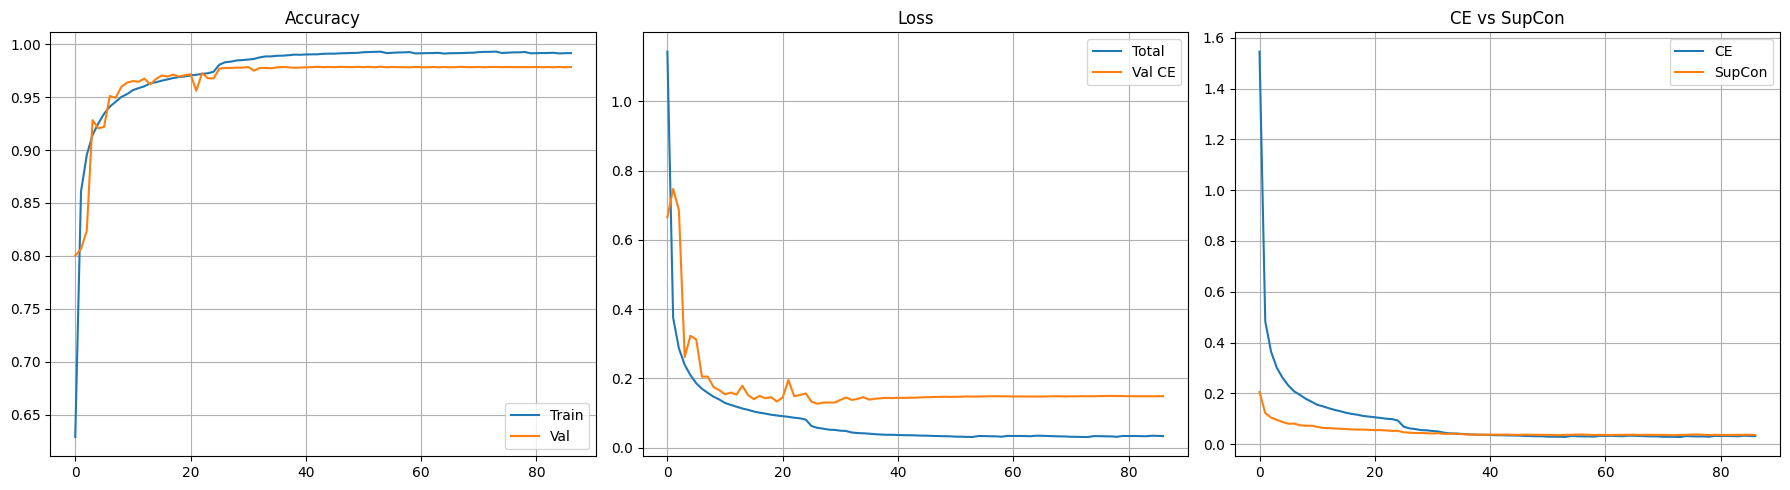

In [ ]:
# =========================================================
# TRAINING: CrossEntropy + SupCon
# =========================================================

PREV_CHECKPOINT = '/kaggle/input/datasets/cuccutkhonglo/resume185/checkpoints'
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def get_inputs(X_dir, X_time, X_size, X_meta, features):
    inputs = {}
    if 'dir' in features: inputs['dir_input'] = X_dir
    if 'time' in features: inputs['time_input'] = X_time
    if 'size' in features: inputs['size_input'] = X_size
    if 'metadata' in features: inputs['metadata_input'] = X_meta
    return inputs

test_inputs = get_inputs(X_dir_test, X_time_test, X_size_test, X_meta_test, config['features_to_use'])

# Augmentation
def augment_batch(b_dir, b_time, b_size, config):
    n, seq_len = b_dir.shape[0], b_dir.shape[1]
    b_dir = b_dir.copy(); b_time = b_time.copy(); b_size = b_size.copy()

    if config.get('prob_time_jitter', 0) > 0:
        apply_mask = (np.random.rand(n, 1, 1) < config['prob_time_jitter'])
        j = (np.random.rand(n, seq_len, 1) - 0.5) * config['aug_time_jitter']
        b_time = np.where(apply_mask, np.clip(b_time + j, 0, None), b_time).astype(np.float32)

    if config.get('prob_size_scale', 0) > 0:
        apply_mask = (np.random.rand(n, 1, 1) < config['prob_size_scale'])
        s = 1.0 + (np.random.rand(n, 1, 1) - 0.5) * config['aug_size_scale']
        b_size = np.where(apply_mask, b_size * s, b_size).astype(np.float32)

    if config.get('prob_dropout', 0) > 0:
        apply_mask = (np.random.rand(n, 1, 1) < config['prob_dropout'])
        drop_mask = (np.random.rand(n, seq_len, 1) > config['aug_dropout_rate']).astype(float)
        final_mask = np.where(apply_mask, drop_mask, 1.0)
        b_dir = (b_dir * final_mask).astype(b_dir.dtype)
        b_time = (b_time * final_mask).astype(np.float32)
        b_size = (b_size * final_mask).astype(np.float32)

    if config.get('prob_noise', 0) > 0:
        apply_mask = (np.random.rand(n, 1, 1) < config['prob_noise'])
        ns = config['aug_noise_std']
        b_time = np.where(apply_mask, np.clip(b_time + np.random.randn(n, seq_len, 1)*ns, 0, None), b_time).astype(np.float32)
        b_size = np.where(apply_mask, np.clip(b_size + np.random.randn(n, seq_len, 1)*ns, 0, None), b_size).astype(np.float32)

    return np.nan_to_num(b_dir), np.nan_to_num(b_time), np.nan_to_num(b_size)

# Train step
@tf.function
def train_step(inputs, y_true):
    with tf.GradientTape() as tape:
        class_pred, embeddings = model(inputs, training=True)
        ce_loss = ce_loss_fn(y_true, class_pred)
        int_labels = tf.argmax(y_true, axis=1)
        sc_loss = supcon_loss_fn(embeddings, int_labels)
        total = (1 - SUPCON_ALPHA) * ce_loss + SUPCON_ALPHA * sc_loss
    grads = tape.gradient(total, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total, ce_loss, sc_loss, class_pred

# =========================================================
# CHECK FOR EXISTING CHECKPOINT
# =========================================================
start_epoch = 0
best_val_loss = float('inf')
history = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[], 'ce_loss':[], 'sc_loss':[]}

latest_ckpt = os.path.join(CHECKPOINT_DIR, 'latest.weights.h5')
history_path = os.path.join(CHECKPOINT_DIR, 'history.npy')

prev_latest = os.path.join(PREV_CHECKPOINT, 'latest.weights.h5')
prev_history = os.path.join(PREV_CHECKPOINT, 'history.npy')

if os.path.exists(latest_ckpt) and os.path.exists(history_path):
    print('Loading current checkpoint...')
    model.load_weights(latest_ckpt)
    saved = np.load(history_path, allow_pickle=True).item()
    history = saved['history']
    start_epoch = saved['epoch'] + 1
    best_val_loss = saved['best_val_loss']
    current_lr = saved.get('lr', config['learning_rate'])
    optimizer.learning_rate.assign(current_lr)
    print(f'Resumed from epoch {start_epoch}, best_val_loss={best_val_loss:.4f}, lr={current_lr}')
elif os.path.exists(prev_latest) and os.path.exists(prev_history):
    print('Loading checkpoint from previous version...')
    model.load_weights(prev_latest)
    saved = np.load(prev_history, allow_pickle=True).item()
    history = saved['history']
    start_epoch = saved['epoch'] + 1
    best_val_loss = saved['best_val_loss']
    current_lr = saved.get('lr', config['learning_rate'])
    optimizer.learning_rate.assign(current_lr)
    print(f'Resumed from epoch {start_epoch}, best_val_loss={best_val_loss:.4f}, lr={current_lr}')
else:
    print('No checkpoint found, starting fresh')
    current_lr = config['learning_rate']

# =========================================================
# TRAINING LOOP
# =========================================================
batch_size = config['batch_size']
max_epochs = config['max_epochs']
n_train = len(y_train)

# Val split
val_frac = config.get('val_size', 0.05)
val_n = int(n_train * val_frac)
train_n = n_train - val_n
all_idx = np.arange(n_train)
np.random.shuffle(all_idx)
train_idx = all_idx[:train_n]
val_idx = all_idx[train_n:]

steps_per_epoch = train_n // batch_size
patience_counter = 0
lr_patience_counter = 0
best_weights = None

print(f'\nTraining: {train_n} train, {val_n} val, {batch_size} batch, {steps_per_epoch} steps/epoch')
print(f'Max epochs: {max_epochs}, LR patience: {config["lr_patience"]}, ES patience: {config["base_patience"]}')
start_time = time.time()

for epoch in range(start_epoch, max_epochs):
    np.random.shuffle(train_idx)
    epoch_loss, epoch_ce, epoch_sc, epoch_correct, epoch_total = [], [], [], 0, 0
    
    # --- Training ---
    pbar = tqdm(range(steps_per_epoch), desc=f'Epoch {epoch+1}/{max_epochs}', leave=True)
    for step in pbar:
        idx = train_idx[step*batch_size : (step+1)*batch_size]
        b_dir = X_dir_train[idx].copy()
        b_time = X_time_train[idx].copy()
        b_size = X_size_train[idx].copy()
        b_meta = X_meta_train[idx].copy()
        
        b_dir, b_time, b_size = augment_batch(b_dir, b_time, b_size, config)
        batch_inputs = get_inputs(b_dir, b_time, b_size, b_meta, config['features_to_use'])
        
        total, ce, sc, pred = train_step(batch_inputs, y_train[idx])
        
        epoch_loss.append(total.numpy())
        epoch_ce.append(ce.numpy())
        epoch_sc.append(sc.numpy())
        
        pred_cls = tf.argmax(pred, axis=1).numpy()
        true_cls = np.argmax(y_train[idx], axis=1)
        epoch_correct += np.sum(pred_cls == true_cls)
        epoch_total += len(idx)
        
        pbar.set_postfix({
            'loss': f'{np.mean(epoch_loss[-10:]):.4f}',
            'acc': f'{epoch_correct/epoch_total:.4f}',
            'CE': f'{np.mean(epoch_ce[-10:]):.4f}',
            'SC': f'{np.mean(epoch_sc[-10:]):.4f}'
        })
    
    train_acc = epoch_correct / epoch_total
    avg_loss = np.mean(epoch_loss)
    
    # --- Validation ---
    val_losses, val_correct, val_total = [], 0, 0
    for step in range(0, len(val_idx), batch_size):
        idx = val_idx[step : step+batch_size]
        if len(idx) == 0: continue
        v_inputs = get_inputs(
            X_dir_train[idx], X_time_train[idx],
            X_size_train[idx], X_meta_train[idx],
            config['features_to_use'])
        v_class, _ = model(v_inputs, training=False)
        v_loss = ce_loss_fn(y_train[idx], v_class)
        val_losses.append(v_loss.numpy())
        val_correct += np.sum(tf.argmax(v_class, axis=1).numpy() == np.argmax(y_train[idx], axis=1))
        val_total += len(idx)
    
    val_loss = np.mean(val_losses)
    val_acc = val_correct / val_total if val_total > 0 else 0
    
    # Save history
    history['loss'].append(avg_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    history['ce_loss'].append(np.mean(epoch_ce))
    history['sc_loss'].append(np.mean(epoch_sc))
    
    elapsed = time.time() - start_time
    print(f'  => loss: {avg_loss:.4f} (CE:{np.mean(epoch_ce):.4f} SC:{np.mean(epoch_sc):.4f}) '
          f'acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f} | '
          f'lr: {current_lr:.6f} | {elapsed:.0f}s')
    
    # --- LR Scheduler + Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.get_weights()
        patience_counter = 0
        lr_patience_counter = 0
        model.save_weights(os.path.join(CHECKPOINT_DIR, 'best.weights.h5'))
        print(f'  ** New best! Saved checkpoint **')
    else:
        patience_counter += 1
        lr_patience_counter += 1
    
    if lr_patience_counter >= config['lr_patience']:
        current_lr = max(current_lr * 0.3, 1e-6)
        optimizer.learning_rate.assign(current_lr)
        lr_patience_counter = 0
        print(f'  -> LR reduced to {current_lr:.6f}')
    
    # Save latest checkpoint (moi epoch)
    model.save_weights(latest_ckpt)
    np.save(history_path, {
        'history': history, 'epoch': epoch,
        'best_val_loss': best_val_loss, 'lr': current_lr
    })
    
    if patience_counter >= config['base_patience']:
        print(f'  Early stopping at epoch {epoch+1}')
        break

# Restore best
best_ckpt = os.path.join(CHECKPOINT_DIR, 'best.weights.h5')
if os.path.exists(best_ckpt):
    model.load_weights(best_ckpt)
    print(f'Restored best weights (val_loss: {best_val_loss:.4f})')

print(f'Total training time: {time.time() - start_time:.1f}s')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history['accuracy'], label='Train'); axes[0].plot(history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['loss'], label='Total'); axes[1].plot(history['val_loss'], label='Val CE')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True)
axes[2].plot(history.get('ce_loss', []), label='CE'); axes[2].plot(history.get('sc_loss', history.get('supcon_loss', [])), label='SupCon')
axes[2].set_title('CE vs SupCon'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.savefig('training_history.png', dpi=150); plt.show()

Generating predictions...


I0000 00:00:1779151484.986279      72 service.cc:152] XLA service 0x7cf19425d3b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779151484.986361      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779151484.986369      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-05-19 00:44:48.182780: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.73 = (f32[256,128,1,79]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,81]{3,2,1,0} %bitcast.8520, f32[128,128,1,3]{3,2,1,0} %bitcast.8524), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_type="Conv2D" op_name="functional_1/res3b1_branch2b_dir_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0

  3/464 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step

I0000 00:00:1779151492.537444      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


464/464 ━━━━━━━━━━━━━━━━━━━━ 44s 74ms/step
MODEL EVALUATION (VAR-CNN + SupCon)
Features:  ['dir', 'time', 'size', 'metadata']
Classes:   300
SupCon:    alpha=0.3, temp=0.1
Accuracy:  0.9763
Precision: 0.9772
Recall:    0.9763

Classification Report:
                                                                           precision    recall  f1-score   support

                                                                  24tv_ua       1.00      0.98      0.99        50
                                                             about_google       1.00      1.00      1.00        50
                                                              acronis_com       0.85      1.00      0.92        50
                                                                anchor_fm       1.00      1.00      1.00        50
                                                               aniwave_to       1.00      0.92      0.96        50
                                                           

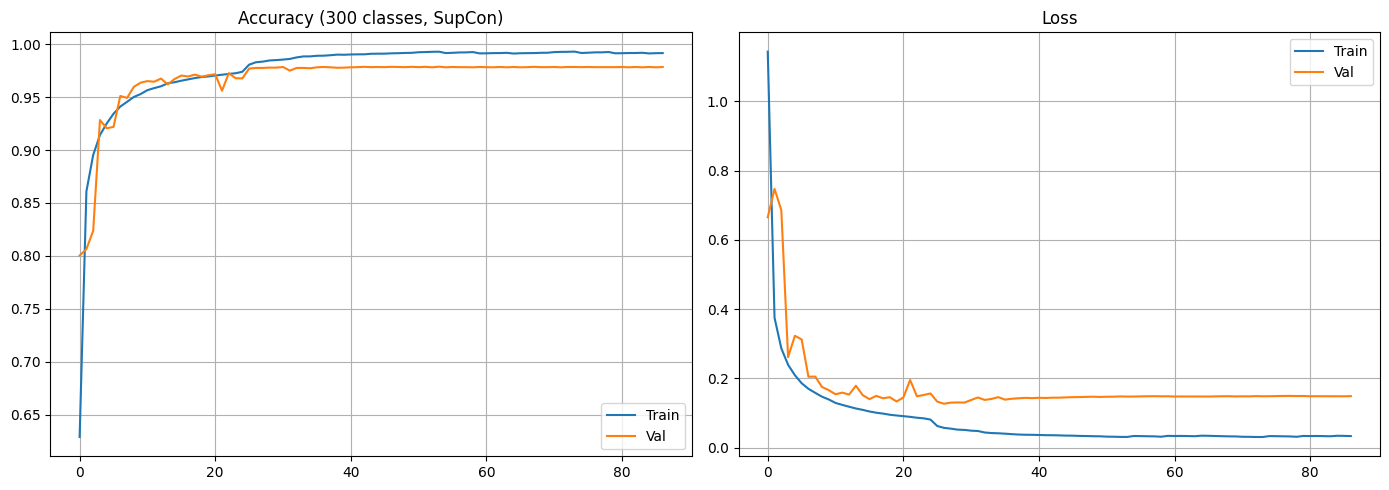

Done!


In [6]:
# =========================================================
# EVALUATION
# =========================================================
print('Generating predictions...')
y_pred_probs, _ = model.predict(test_inputs)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true_classes, y_pred_classes)
prec = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
rec = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
clf_report = classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_, zero_division=0)

result_text = f"""=====================================
MODEL EVALUATION (VAR-CNN + SupCon)
=====================================
Features:  {config['features_to_use']}
Classes:   {num_classes}
SupCon:    alpha={SUPCON_ALPHA}, temp={SUPCON_TEMP}
Accuracy:  {acc:.4f}
Precision: {prec:.4f}
Recall:    {rec:.4f}

Classification Report:
{clf_report}
"""
with open('evaluation_results.txt', 'w') as f:
    f.write(result_text)
print(result_text)

# Top-5
top5 = sum(1 for i in range(len(y_true_classes)) if y_true_classes[i] in np.argsort(y_pred_probs[i])[-5:])
print(f'Top-5 Accuracy: {top5/len(y_true_classes):.4f}')

# Per-class
print(f'\nPer-class accuracy:')
for c in range(num_classes):
    m = y_true_classes == c
    if m.sum() > 0:
        print(f'  {label_encoder.classes_[c]:30s}: {np.mean(y_pred_classes[m]==y_true_classes[m]):.2%} ({m.sum()} samples)')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['accuracy'], label='Train'); ax1.plot(history['val_accuracy'], label='Val')
ax1.set_title(f'Accuracy ({num_classes} classes, SupCon)'); ax1.legend(); ax1.grid(True)
ax2.plot(history['loss'], label='Train'); ax2.plot(history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.savefig('final_results.png', dpi=150); plt.show()
print('Done!')
